# 4.10 IC Task 4.10 Part 1

# Table of Contents

__01. Step 1 - Importing analysis and visualization libraries and dataframe__

__02. Step 2 - Evaluating and addressing any PII security implications in the data__

__03. Step 3 - Create a region segmentation column for region-skewed analysis__

__04. Step 4 - Create exclusion flag for low-activity customers and exclude them from the data__

__05. Step 5 - Create a profiling variable based on age, income and number of dependents__

__06. Step 6 - Create an appropriate visualization to show the distribution of profiles__

__07. Step 7 - Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure__ 

__08. Step 8 - Compare your customer profiles with regions and departments. Can you identify a link between them?__

__09. Poking around__

__10. Export dataframe__

# 01. Step 1 - Importing analysis and visualization libraries and dataframe

In [519]:
# Import analysis and visualization libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [9]:
# Import latest, combined, up-to-date dataframe from prior Task 4.9 for Project

path = r'C:\Users\dirk8\CareerFoundry Projects\03-2025 Instacart Basket Analysis'
ords_prods_cust = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust.pkl'))

In [10]:
# Check the output
ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,order_frequency_flag,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423


In [10]:
# Check the output middle columns not visible in the output above

ords_prods_cust.iloc[0:2, 9:22]

,product_name,aisle_id,department_id,prices,price_range_loc,busiest_day,busiest_period_of_day,max_order,loyalty_flag,mean_price_per_order,spending_flag,median_days_since_prior_order,order_frequency_flag
0,Soda,77,7,9.0,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
1,Organic Unsweetened Vanilla Almond Milk,91,16,12.5,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer


In [12]:
# Check the dimensions
ords_prods_cust.shape

(32399732, 31)

# 02. Step 2 - Consider any security implications that might exist for the data. You'll need to address any PII data in the data before continuing your analysis.

In [15]:
# Check columns types of data
ords_prods_cust.columns

Index(['order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_period_of_day', 'max_order', 'loyalty_flag',
       'mean_price_per_order', 'spending_flag',
       'median_days_since_prior_order', 'order_frequency_flag', 'first_name',
       'last_name', 'gender', 'state_name', 'age', 'date_joined',
       'number_dependents', 'family_status', 'income'],
      dtype='object')

__PII data for this student project was sanitized to create fictitious customer data in the originally-uploaded raw dataset.  Price data was also fictionalized to protect the data provider's proprietary pricing strategy.  These measures addressed any PII security and proprietary data concerns for the IC dataset.__

# 03. Step 3 - Create a region segmentation column for region-skewed analysis

In [94]:
# Step 3: Create a regional segmentation of the data, by creating a region column based on the state name
# Use the state-to-region mapping in the Task-provided link to a Wikipedia article

In [18]:
# Define state_name mapping to region (a new column to be created) values, saving them into variables stored as lists

northeast = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut', 'New York', 'Pennsylvania', 'New Jersey']
midwest = ['Wisconsin', 'Michigan', 'Illinois', 'Indiana', 'Ohio', 'North Dakota', 'South Dakota', 'Nebraska', 'Kansas', 'Minnesota', 'Iowa', 'Missouri']
south = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Kentucky', 'Tennessee', 'Mississippi', 'Alabama', 'Oklahoma', 'Texas', 'Arkansas', 'Louisiana']
west = ['Idaho', 'Montana', 'Wyoming', 'Nevada', 'Utah', 'Colorado', 'Arizona', 'New Mexico', 'Alaska', 'Washington', 'Oregon', 'California', 'Hawaii']

In [20]:
# Use .loc[] property to create a new column 'region' whose values are based on .isin-based conditional criteria
# Then output a frequency distribution to verify that all records were assigned to a region value

In [21]:
ords_prods_cust.loc[ords_prods_cust['state_name'].isin(northeast), 'region'] = 'Northeast'

In [22]:
ords_prods_cust.loc[ords_prods_cust['state_name'].isin(midwest), 'region'] = 'Midwest'

In [23]:
ords_prods_cust.loc[ords_prods_cust['state_name'].isin(south), 'region'] = 'South'

In [24]:
ords_prods_cust.loc[ords_prods_cust['state_name'].isin(west), 'region'] = 'West'

In [25]:
ords_prods_cust['region'].value_counts(dropna=False)

region
South        10790096
West          8291679
Midwest       7596065
Northeast     5721892
Name: count, dtype: int64

In [26]:
# Check the output

ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income,region
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South


# Determine whether there is a difference in spending habits between the different U.S. regions

__Crosstab__

In [909]:
# Comment: Crosstabs are a common tool for conducting data checks in Python, similar to Pivot Tables in Excel
# (cont.) .crosstab() is a specialized version of the .pivot_table() function, designed for 2 or more categorical variable cross-tabulated freq. counts
# This can be done by creating a crosstab comparing 'region' to 'spending_flag'

crosstab = pd.crosstab(ords_prods_cust['region'], ords_prods_cust['spending_flag'], dropna = False)

In [29]:
#Output the result

crosstab

spending_flag,High spender,Low spender
region,,
Midwest,29265,7566800
Northeast,18639,5703253
South,40577,10749519
West,31238,8260441


__Comment: The resulting table outputs the number of records (e.g. transaction count) in each 'box' but does not adjust for differences in the number of IC customers based in the different regions.  A region with the most customers (i.e. the South, as defined geographically in the Wikipedia article) would show the most orders.  Customer-level metrics may be more useful for cross-region comparisons.  For this goal, a general pivot_table() approach instead of the crosstab() tool would allow the analysis to move beyond simple records counts.__

# 04. Step 4 - Create exclusion flag for low-activity customers and exclude them from the data

In [31]:
# Step 4: The Instacart CFO isn’t interested in customers who don’t generate much revenue for the app.
# (cont.) Create an exclusion flag for low-activity customers (max order < 5 orders) and exclude them from the data.
# (cont.) Export the sample before removing records that meet the exclusion condition.

low_activity_cust = ords_prods_cust[ords_prods_cust['max_order'] < 5]

In [32]:
# Check the dimensions
low_activity_cust.shape

(1440045, 32)

In [33]:
# Check the output from the middle group of columns

In [34]:
low_activity_cust.iloc[0:2, 9:22]

,product_name,aisle_id,department_id,prices,price_range_loc,busiest_day,busiest_period_of_day,max_order,loyalty_flag,mean_price_per_order,spending_flag,median_days_since_prior_order,order_frequency_flag
360,Organic Raw Agave Nectar,29,13,10.7,Mid-range product,Regularly busy,Most orders,4,New customer,9.189189,Low spender,11.0,Regular customer
361,Organic Soba,66,6,6.7,Mid-range product,Regularly busy,Most orders,4,New customer,9.189189,Low spender,11.0,Regular customer


In [35]:
# Check the output from the outer groups of columns
low_activity_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income,region
360,2717275,5,1,3,12,NaN,15349,1,0,Organic Raw Agave Nectar,...,Janet,Lester,Female,California,75,2018-10-08,0,divorced/widowed,115242,West
361,2717275,5,1,3,12,NaN,21413,2,0,Organic Soba,...,Janet,Lester,Female,California,75,2018-10-08,0,divorced/widowed,115242,West


In [36]:
# Check the frequency distribution of the 'max_order' column values of the sample (a subset dataframe)
low_activity_cust['max_order'].value_counts()

max_order
4    753414
3    686620
2         6
1         5
Name: count, dtype: int64

In [37]:
# Export the created low_activity_cust subset dataframe for backup, prior to deleting these records from the ords_prods_cust dataframe

low_activity_cust.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'low_activity_cust.pkl'))

In [38]:
# Check dimensions of ords_prods_cust dataframe before deleting the 1,440,045 low-activity customer records
ords_prods_cust.shape

(32399732, 32)

# Delete 1,440,045 low-activity customer records from ords_prods_cust dataframe

In [40]:
# Delete rows where 'max_order' column value < 5 from the dataframe, as per CFO's instruction to exclude them from the data
# This is accomplished by overwriting the dataframe to "filter in" those records whose 'max_order' column value >= 5

ords_prods_cust = ords_prods_cust[ords_prods_cust['max_order'] >= 5]

In [41]:
# Check the dimensions
ords_prods_cust.shape

(30959687, 32)

__Verified:  30,959,687 + 1,440,045 = 32,399,732 pre-alteration records__

In [43]:
# Check the output
ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income,region
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South


In [44]:
# Check if there are any 'max_order' column values < 5
verify = ords_prods_cust[ords_prods_cust['max_order'] < 5]

In [45]:
verify

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income,region


In [46]:
# Export the altered ords_prods_cust dataframe as backup
ords_prods_cust.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust_altered.pkl'))

# 05. Step 5 - Create a profiling variable based on age, income and number of dependents

__Create profiling variable 'cust_prof_1' to examine income and number of dependents impact on ordering behavior. We expect to see that motivation (having dependents means more mouths to feed) and ability (income level) will have impact.__

__To test the other thesis posed in Task 4.10 (e.g. that age matters ... ), create a second profiling variable 'cust_prof_2' to examine age and number of dependents impact on ordering behavior. While we expect to see dependents status as impactful, based on prior analysis of the dataset, age is not expected to move the needle much (unless age 42 is a trigger or inflection point, since a prior Exercise scatterplot revealed a large, abrupt jump in income at that age.__

In [942]:
# Check the total number of customers in the dataset
ords_prods_cust['user_id'].nunique()

162631

In [944]:
# Check number of customers that make up each 'family_status' category

ords_prods_cust.groupby('family_status')['user_id'].nunique()

family_status
divorced/widowed                     13831
living with parents and siblings      7608
married                             114296
single                               26896
Name: user_id, dtype: int64

# First profiling variable: Income & Number of Dependents

__We use $125,000 as the condition separating higher and lower income and no dependents versus 1+ dependents as the dependents status condition for grouping.  This gives us 4 categories to examine.__

In [454]:
ords_prods_cust.loc[(ords_prods_cust['income'] < 125000) & (ords_prods_cust['number_dependents'] == 0), 'cust_prof_1'] = 'LI-ND'

In [455]:
ords_prods_cust.loc[(ords_prods_cust['income'] < 125000) & (ords_prods_cust['number_dependents'] > 0), 'cust_prof_1'] = 'LI-D'

In [456]:
ords_prods_cust.loc[(ords_prods_cust['income'] >= 125000) & (ords_prods_cust['number_dependents'] == 0), 'cust_prof_1'] = 'HI-ND'

In [457]:
ords_prods_cust.loc[(ords_prods_cust['income'] >= 125000) & (ords_prods_cust['number_dependents'] > 0), 'cust_prof_1'] = 'HI-D'

In [458]:
# Check the output
ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income,region,cust_prof_1
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South,LI-D
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423,South,LI-D


In [459]:
# Check the dimensions
ords_prods_cust.shape

(30959687, 33)

In [460]:
# Check the frequency distribution of the created first profiling variable ('cust_prof_1')
ords_prods_cust['cust_prof_1'].value_counts(dropna=False)

cust_prof_1
LI-D     17043237
HI-D      6177942
LI-ND     5642590
HI-ND     2095918
Name: count, dtype: int64

In [512]:
# Check the frequency distribution of number of customers in each 'cust_prof_1' category
ords_prods_cust.groupby('cust_prof_1')['user_id'].nunique()

cust_prof_1
HI-D     30585
HI-ND    10230
LI-D     91319
LI-ND    30497
Name: user_id, dtype: int64

# Second profiling variable: Age & Number of Dependents

__We use 42 years of age as the condition separating the Under and Over Mid Age groups (and because a prior Exercise scatterplot showed a large jump in income at that age) and no dependents versus 1+ dependents as the dependents status condition for grouping.  This gives us 4 categories to examine.__

In [461]:
ords_prods_cust.loc[(ords_prods_cust['age'] < 42) & (ords_prods_cust['number_dependents'] == 0), 'cust_prof_2'] = 'MU-ND'

In [462]:
ords_prods_cust.loc[(ords_prods_cust['age'] >= 42) & (ords_prods_cust['number_dependents'] > 0), 'cust_prof_2'] = 'MO-D'

In [463]:
ords_prods_cust.loc[(ords_prods_cust['age'] < 42) & (ords_prods_cust['number_dependents'] > 0), 'cust_prof_2'] = 'MU-D'

In [464]:
ords_prods_cust.loc[(ords_prods_cust['age'] >= 42) & (ords_prods_cust['number_dependents'] == 0), 'cust_prof_2'] = 'MO-ND'

In [465]:
# Check the output
ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,gender,state_name,age,date_joined,number_dependents,family_status,income,region,cust_prof_1,cust_prof_2
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Female,Alabama,31,2019-02-17,3,married,40423,South,LI-D,MU-D
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Female,Alabama,31,2019-02-17,3,married,40423,South,LI-D,MU-D


In [466]:
# Check the dimensions
ords_prods_cust.shape

(30959687, 34)

In [467]:
# Check the frequency distribution of the created second profiling variable ('cust_prof_2')
ords_prods_cust['cust_prof_2'].value_counts(dropna=False)

cust_prof_2
MO-D     14523305
MU-D      8697874
MO-ND     4838489
MU-ND     2900019
Name: count, dtype: int64

In [514]:
# Check the frequency distribution of number of customers in each 'cust_prof_2' category
ords_prods_cust.groupby('cust_prof_2')['user_id'].nunique()

cust_prof_2
MO-D     76618
MO-ND    25352
MU-D     45286
MU-ND    15375
Name: user_id, dtype: int64

# 06. Step 6 - Create an appropriate visualization to show the distribution of profiles

# First profiling variable: Income & Number of Dependents

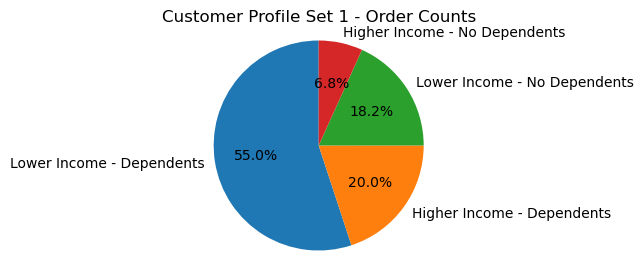

In [701]:
# We start with a pie chart showing income/dependents status profile proportions for 'cust_prof_1'
# For label clarity, create a dictionary mapping category acronyms to full labels

label_map = {
    "LI-D": "Lower Income - Dependents",
    "LI-ND": "Lower Income - No Dependents",
    "HI-D": "Higher Income - Dependents",
    "HI-ND": "Higher Income - No Dependents"
}

# Get the frequency distribution of the order counts
freq_dist = ords_prods_cust['cust_prof_1'].value_counts(dropna=False)

# Replace acronyms with full descriptions

full_labels = [label_map[acronym] for acronym in freq_dist.index]

# Create pie chart

pie_1 = plt.figure(figsize = (4,3))
plt.pie(freq_dist, labels = full_labels, autopct = '%1.1f%%', startangle = 90)
plt.title('Customer Profile Set 1 - Order Counts')
plt.axis('equal') # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [703]:
# Export pie chart
pie_1.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'pie_1_ords.png'), bbox_inches = 'tight')

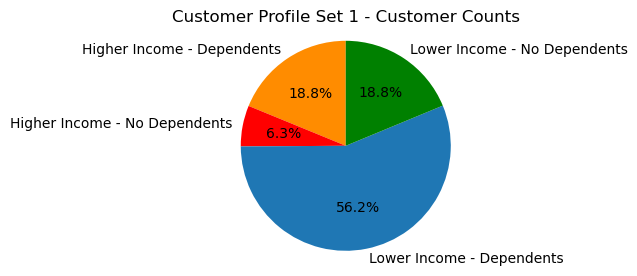

In [614]:
# We want a comparative pie chart for the same variable but looking at customer count proportions rather than order count proportions
# For label clarity, create a dictionary mapping category acronyms to full labels

label_map = {
    "LI-D": "Lower Income - Dependents",
    "LI-ND": "Lower Income - No Dependents",
    "HI-D": "Higher Income - Dependents",
    "HI-ND": "Higher Income - No Dependents"
}

# Next we get the frequency distribution of customer groupings to compare proportions of customer counts versus order counts via the 2 pie charts
freq_dist1 = ords_prods_cust.groupby('cust_prof_1')['user_id'].nunique(dropna = False)

# Replace acronyms with full descriptions

full_labels = [label_map[acronym] for acronym in freq_dist1.index]

# Match pie wedge colors to previous pie chart output colors

colors = ['darkorange', 'red', '#1f77b4', 'green']

# Create pie chart

pie_2 = plt.figure(figsize = (4,3))
plt.pie(freq_dist1, labels = full_labels, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Customer Profile Set 1 - Customer Counts')
plt.axis('equal') # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [616]:
# Export pie chart
pie_2.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'pie_2_cust.png'), bbox_inches = 'tight')

# Second profiling variable: Age & Number of Dependents

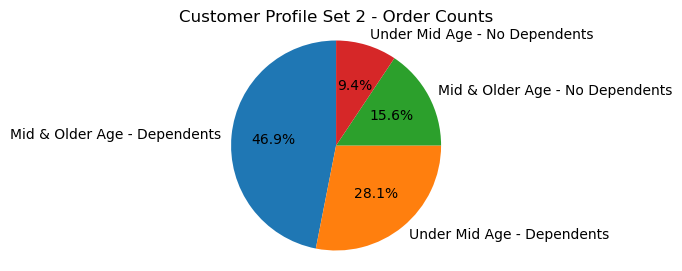

In [618]:
# Now we create a pie chart showing age/dependents status profile proportions for 'cust_prof_2'
# For label clarity, create a dictionary mapping category acronyms to full labels

label_map = {
    "MO-D": "Mid & Older Age - Dependents",
    "MO-ND": "Mid & Older Age - No Dependents",
    "MU-D": "Under Mid Age - Dependents",
    "MU-ND": "Under Mid Age - No Dependents"
}

# Get the frequency distribution of the order counts
freq_dist3 = ords_prods_cust['cust_prof_2'].value_counts(dropna=False)

# Replace acronyms with full descriptions

full_labels = [label_map[acronym] for acronym in freq_dist3.index]

# Create pie chart

pie_3 = plt.figure(figsize = (4,3))
plt.pie(freq_dist3, labels = full_labels, autopct = '%1.1f%%', startangle = 90)
plt.title('Customer Profile Set 2 - Order Counts')
plt.axis('equal') # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [620]:
# Export pie chart
pie_3.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'pie_3_ords.png'), bbox_inches = 'tight')

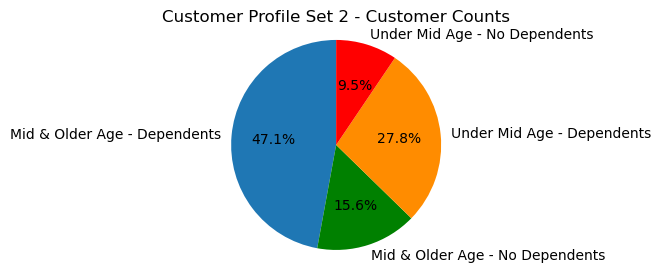

In [664]:
# We want a comparative pie chart for the same variable but looking at customer count proportions rather than order count proportions
# For label clarity, create a dictionary mapping category acronyms to full labels

label_map = {
    'MO-D': 'Mid & Older Age - Dependents',
    'MO-ND': 'Mid & Older Age - No Dependents',
    'MU-D': 'Under Mid Age - Dependents',
    'MU-ND': 'Under Mid Age - No Dependents'
}

# Next we get the frequency distribution of customer groupings to compare proportions of customer counts versus order counts via the 2 pie charts
freq_dist4 = ords_prods_cust.groupby('cust_prof_2')['user_id'].nunique(dropna = False)

# Replace acronyms with full descriptions

full_labels = [label_map[acronym] for acronym in freq_dist4.index]

# Match pie wedge colors to previous pie chart output colors

colors = ['#1f77b4', 'green', 'darkorange', 'red']

# Create pie chart

pie_4 = plt.figure(figsize = (4,3))
plt.pie(freq_dist4, labels = full_labels, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Customer Profile Set 2 - Customer Counts')
plt.axis('equal') # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [665]:
# Export pie chart
pie_4.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'pie_4_cust.png'), bbox_inches = 'tight')

# 07. Step 7 - Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure 

# First profiling variable: usage frequency

In [705]:
# Income-Dependents status groupings ('cust_prof_1' variable) statistics for usage frequency
ords_prods_cust.groupby('cust_prof_1').agg({'days_since_prior_order': ['max', 'mean', 'min', 'median']}).round(1)

days_since_prior_order                  
                               max  mean  min median
cust_prof_1                                         
HI-D                          30.0  10.8  0.0    7.0
HI-ND                         30.0  10.6  0.0    7.0
LI-D                          30.0  10.8  0.0    7.0
LI-ND                         30.0  10.8  0.0    7.0

__Comment: See 'cust_prof_1' customer profile category label descriptions in Step 6__

# First profiling variable: expenditure

In [786]:
# To get stats for expenditure we first create an 'expenditure' column that groups by 'user_id' and 'order_number' and then sums 'prices'
# This gives us the total expenditure on a customer ('user_id') order (on a given day for a given hour)
ords_prods_cust['expenditure'] = ords_prods_cust.groupby(['user_id', 'order_number'])['prices'].transform('sum')

In [723]:
# Check the dimensions
ords_prods_cust.shape

(30959687, 35)

In [735]:
# Check the output
ords_prods_cust.loc[0:11, ['user_id','order_number','product_name','prices','expenditure']]

,user_id,order_number,product_name,prices,expenditure
0,1,1,Soda,9.0,31.6
1,1,1,Organic Unsweetened Vanilla Almond Milk,12.5,31.6
2,1,1,Original Beef Jerky,4.4,31.6
3,1,1,Aged White Cheddar Popcorn,4.7,31.6
4,1,1,XL Pick-A-Size Paper Towel Rolls,1.0,31.6
5,1,2,Soda,9.0,35.4
6,1,2,Pistachios,3.0,35.4
7,1,2,Original Beef Jerky,4.4,35.4
8,1,2,Bag of Organic Bananas,10.3,35.4
9,1,2,Aged White Cheddar Popcorn,4.7,35.4


In [739]:
# Income-Dependents status groupings ('cust_prof_1' variable) statistics for expenditure
ords_prods_cust.groupby('cust_prof_1').agg({'expenditure': ['max', 'mean', 'min', 'median']}).round(1)

expenditure                   
                    max   mean  min median
cust_prof_1                               
HI-D             1047.4  126.2  1.0  112.3
HI-ND             621.2  126.1  1.0  112.0
LI-D             1092.2  121.0  1.0  106.3
LI-ND             875.0  120.2  1.0  105.7

__Comment: See 'cust_prof_1' customer profile category label descriptions in Step 6__

# Second profiling variable: usage frequency

In [740]:
# Age-Dependents status groupings ('cust_prof_2' variable) statistics for usage frequency
ords_prods_cust.groupby('cust_prof_2').agg({'days_since_prior_order': ['max', 'mean', 'min', 'median']}).round(1)

days_since_prior_order                  
                               max  mean  min median
cust_prof_2                                         
MO-D                          30.0  10.8  0.0    7.0
MO-ND                         30.0  10.7  0.0    7.0
MU-D                          30.0  10.8  0.0    7.0
MU-ND                         30.0  10.9  0.0    8.0

__Comment: See 'cust_prof_2' customer profile category label descriptions in Step 6__

# Second profiling variable: expenditure

In [783]:
# Age-Dependents status groupings ('cust_prof_2' variable) statistics for expenditure
ords_prods_cust.groupby('cust_prof_2').agg({'expenditure': ['max', 'mean', 'min', 'median']}).round(1)

expenditure                   
                    max   mean  min median
cust_prof_2                               
MO-D             1092.2  121.9  1.0  107.6
MO-ND             875.0  121.9  1.0  107.4
MU-D              842.1  123.2  1.0  108.4
MU-ND             712.0  121.6  1.0  107.2

__Comment: See 'cust_prof_2' customer profile category label descriptions in Step 6__

# 08. Step 8 - Compare your customer profiles with regions and departments. Can you identify a link between them? Customers may demonstrate different behaviors across regions, which could make this information important.

# First profiling variable: average customer expenditure across regions

In [809]:
# Create a pivot table to see whether average expenditure for income-dependents status customer profiles vary across regions
pivot_table = ords_prods_cust.pivot_table(values = 'expenditure', index = ['cust_prof_1', 'region'], aggfunc = 'mean')

In [813]:
# Use full description names for the income-dependency status category acronyms
# Use a dictionary to rename the categories

category_labels = {
    'HI-D': 'High Income - Dependents',
    'HI-ND': 'High Income - No Dependents',
    'LI-D': 'Low Income - Dependents',
    'LI-ND': 'Low Income - No Dependents'
}

# Use .unstack() to move the 'regions' index to columns, to make it easier to plot grouped bars from the pivot table columns
pivot_table_unstacked = pivot_table.round(1).unstack().rename(index = category_labels)
pivot_table_unstacked

expenditure                        
region                          Midwest Northeast  South   West
cust_prof_1                                                    
High Income - Dependents          124.4     129.0  126.3  125.9
High Income - No Dependents       126.5     121.8  127.9  126.4
Low Income - Dependents           121.1     121.0  120.6  121.3
Low Income - No Dependents        121.1     118.9  121.4  118.8

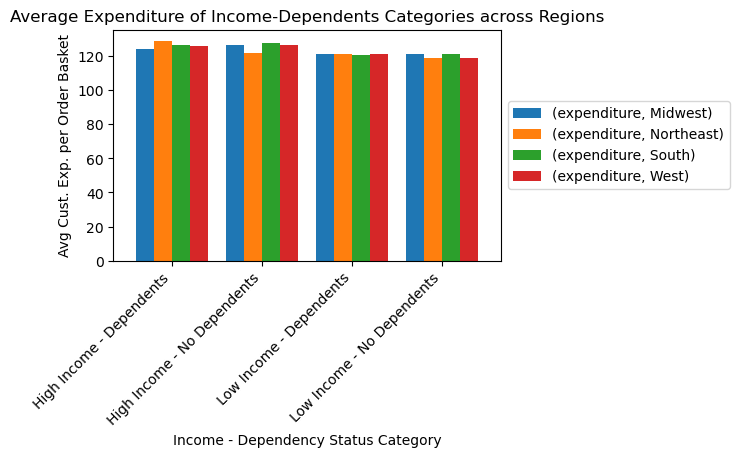

In [827]:
# Create a grouped bar chart from pivot_table_unstacked

cust_prof_reg_exp_bar = pivot_table_unstacked.plot(kind='bar', figsize=(5, 3), width=0.8)

plt.title('Average Expenditure of Income-Dependents Categories across Regions')
plt.xlabel('Income - Dependency Status Category')
plt.ylabel('Avg Cust. Exp. per Order Basket')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha='right')
plt.show()

In [829]:
# Export grouped bar chart
cust_prof_reg_exp_bar.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'cust_prof_reg_exp_bar.png'), bbox_inches = 'tight')

# Second profiling variable: average customer expenditure across regions

In [833]:
# Create a pivot table to see whether average expenditure for age-dependents status customer profiles vary across regions
pivot_table1 = ords_prods_cust.pivot_table(values = 'expenditure', index = ['cust_prof_2', 'region'], aggfunc = 'mean')

In [835]:
# Use full description names for the age-dependency status category acronyms
# Use a dictionary to rename the categories

category_labels1 = {
    'MO-D': 'Mid & Older Age - Dependents',
    'MO-ND': 'Mid & Older Age - No Dependents',
    'MU-D': 'Under Mid Age - Dependents',
    'MU-ND': 'Under Mid Age - No Dependents'
}

# Use .unstack() to move the 'regions' index to columns, to make it easier to plot grouped bars from the pivot table columns
pivot_table_unstacked1 = pivot_table1.round(1).unstack().rename(index = category_labels1)
pivot_table_unstacked1

expenditure                        
region                              Midwest Northeast  South   West
cust_prof_2                                                        
Mid & Older Age - Dependents          121.3     123.6  121.2  122.2
Mid & Older Age - No Dependents       123.1     117.9  123.5  121.5
Under Mid Age - Dependents            123.3     122.4  123.5  123.2
Under Mid Age - No Dependents         121.8     122.6  122.6  119.6

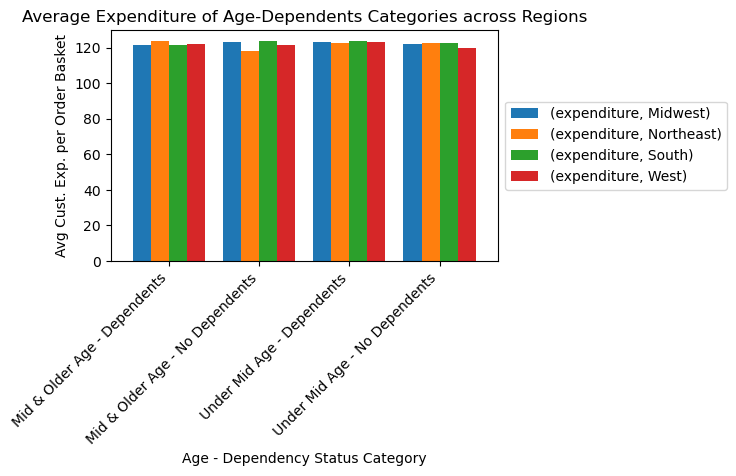

In [837]:
# Create a grouped bar chart from pivot_table_unstacked1

inc_reg_exp_bar = pivot_table_unstacked1.plot(kind='bar', figsize=(5, 3), width=0.8)

plt.title('Average Expenditure of Age-Dependents Categories across Regions')
plt.xlabel('Age - Dependency Status Category')
plt.ylabel('Avg Cust. Exp. per Order Basket')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha='right')
plt.show()

In [840]:
# Export grouped bar chart
inc_reg_exp_bar.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'inc_reg_exp_bar.png'), bbox_inches = 'tight')

# First profiling variable: average customer expenditure across departments

In [845]:
# Create a pivot table to see whether average expenditure for income-dependents status customer profiles vary across departments
pivot_table2 = ords_prods_cust.pivot_table(values = 'expenditure', index = ['department_id', 'cust_prof_1'], aggfunc = 'mean')

In [859]:
# Use full description name for the department_id via a dictionary

department_labels = {1: 'frozen', 2: 'other', 3: 'bakery', 4: 'produce', 5: 'alcohol',6: 'international', 7: 'beverages', 8: 'pets', 9: 'dry goods pasta',10: 'bulk', 11: 'personal care', 12: 'meat seafood', 13: 'pantry',14: 'breakfast', 15: 'canned goods', 16: 'dairy eggs', 17: 'household',18: 'babies', 19: 'snacks', 20: 'deli', 21: 'missing'}

category_labels2 = {
    'HI-D': 'High Income - Dependents',
    'HI-ND': 'High Income - No Dependents',
    'LI-D': 'Low Income - Dependents',
    'LI-ND': 'Low Income - No Dependents'
}

# Use .unstack() to move the 'cust_prof_1' index to columns, to make it easier to plot grouped bars from the pivot table columns
pivot_table_unstacked2 = pivot_table2.round(1).unstack().rename(index = department_labels, columns = category_labels2)
pivot_table_unstacked2

expenditure                              \
cust_prof_1     High Income - Dependents High Income - No Dependents   
department_id                                                          
frozen                             129.1                       128.9   
other                              110.7                       116.0   
bakery                             126.7                       126.7   
produce                            126.0                       126.0   
alcohol                             84.1                        82.6   
international                      135.5                       135.8   
beverages                          113.8                       114.2   
pets                               122.9                       127.3   
dry goods pasta                    137.9                       138.3   
bulk                               120.8                       123.7   
personal care                      113.3                       115.4   
meat seafood                       134.6                       133.3   
pantry                             129.6                       129.7   
breakfast                          129.7                       131.1   
canned goods                       138.1                       136.7   
dairy eggs                         124.6                       124.0   
household                          118.0                       118.8   
babies                             151.3                       147.9   
snacks                             126.4                       126.1   
deli                               128.7                       129.7   
missing                            131.7                       128.3   

                                                                    
cust_prof_1     Low Income - Dependents Low Income - No Dependents  
department_id                                                       
frozen                            123.8                      124.5  
other                             107.7                      108.8  
bakery                            123.0                      122.4  
produce                           121.3                      120.4  
alcohol                            80.0                       75.0  
international                     130.7                      129.9  
beverages                         107.3                      106.9  
pets                              117.1                      118.1  
dry goods pasta                   134.7                      134.2  
bulk                              114.9                      109.6  
personal care                     109.5                      108.1  
meat seafood                      132.9                      130.9  
pantry                            124.3                      123.5  
breakfast                         124.5                      122.9  
canned goods                      134.1                      133.0  
dairy eggs                        121.0                      119.8  
household                         110.3                      108.9  
babies                            149.7                      153.5  
snacks                            116.0                      115.1  
deli                              124.4                      124.3  
missing                           125.4                      127.1

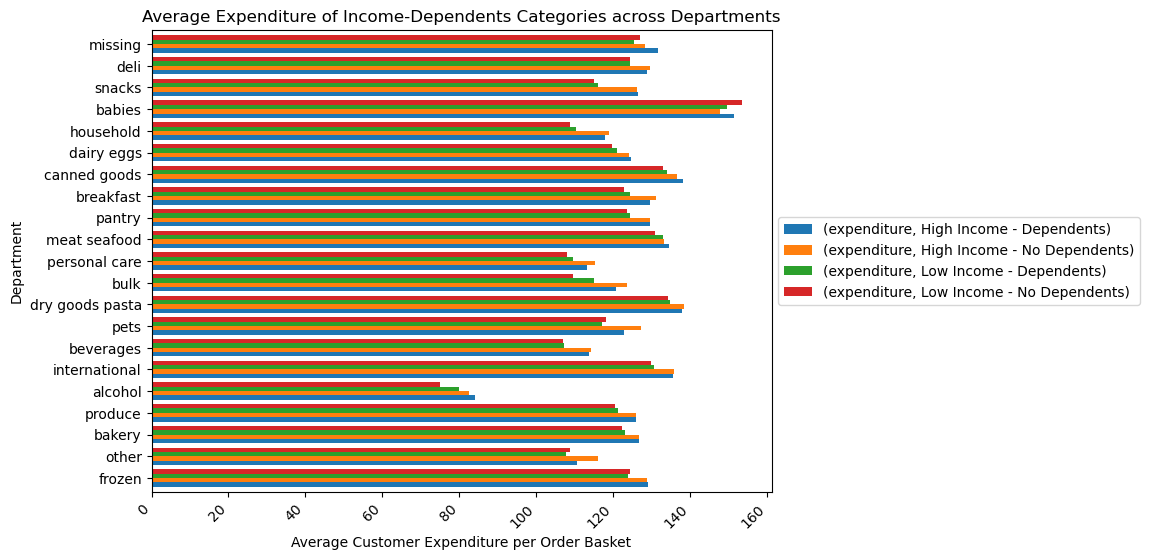

In [867]:
# Create a grouped bar chart from pivot_table_unstacked2

inc_dept_exp_bar = pivot_table_unstacked2.plot(kind='barh', figsize=(8, 6), width=0.8)

plt.title('Average Expenditure of Income-Dependents Categories across Departments')
plt.xlabel('Average Customer Expenditure per Order Basket')
plt.ylabel('Department')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha='right')
plt.show()

In [869]:
# Export grouped horizontal bar chart
inc_dept_exp_bar.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'inc_dept_exp_bar.png'), bbox_inches = 'tight')

# Second profiling variable: average customer expenditure across departments

In [875]:
# Create a pivot table to see whether average expenditure for age-dependents status customer profiles vary across departments
pivot_table3 = ords_prods_cust.pivot_table(values = 'expenditure', index = ['department_id', 'cust_prof_2'], aggfunc = 'mean')

In [877]:
# Use full description name for the department_id via a dictionary
# Use full description name for 'cust_prof_2' categories via a dictionary

department_labels1 = {1: 'frozen', 2: 'other', 3: 'bakery', 4: 'produce', 5: 'alcohol',6: 'international', 7: 'beverages', 8: 'pets', 9: 'dry goods pasta',10: 'bulk', 11: 'personal care', 12: 'meat seafood', 13: 'pantry',14: 'breakfast', 15: 'canned goods', 16: 'dairy eggs', 17: 'household',18: 'babies', 19: 'snacks', 20: 'deli', 21: 'missing'}

category_labels3 = {
    'MO-D': 'Mid & Older Age - Dependents',
    'MO-ND': 'Mid & Older Age - No Dependents',
    'MU-D': 'Under Mid Age - Dependents',
    'MU-ND': 'Under Mid Age - No Dependents'
}

# Use .unstack() to move the 'cust_prof_2' index to columns, to make it easier to plot grouped bars from the pivot table columns
pivot_table_unstacked3 = pivot_table3.round(1).unstack().rename(index = department_labels1, columns = category_labels3)
pivot_table_unstacked3

expenditure                                  \
cust_prof_2     Mid & Older Age - Dependents Mid & Older Age - No Dependents   
department_id                                                                  
frozen                                 124.6                           125.5   
other                                  108.5                           112.0   
bakery                                 123.5                           123.1   
produce                                122.1                           122.0   
alcohol                                 79.3                            77.7   
international                          131.6                           131.8   
beverages                              108.3                           109.2   
pets                                   119.5                           120.9   
dry goods pasta                        135.1                           135.1   
bulk                                   114.6                           114.0   
personal care                          110.4                           110.2   
meat seafood                           132.9                           131.9   
pantry                                 125.5                           125.4   
breakfast                              124.9                           125.3   
canned goods                           134.8                           134.1   
dairy eggs                             121.6                           121.0   
household                              112.6                           112.3   
babies                                 150.3                           149.9   
snacks                                 117.5                           118.0   
deli                                   124.9                           126.1   
missing                                127.1                           126.9   

                                                                          
cust_prof_2     Under Mid Age - Dependents Under Mid Age - No Dependents  
department_id                                                             
frozen                               126.3                         126.0  
other                                108.7                         108.6  
bakery                               124.9                         124.3  
produce                              123.2                         121.7  
alcohol                               84.2                          76.9  
international                        132.8                         131.0  
beverages                            110.1                         108.2  
pets                                 117.3                         121.2  
dry goods pasta                      136.4                         135.6  
bulk                                 119.1                         111.8  
personal care                        110.6                         110.0  
meat seafood                         134.1                         131.0  
pantry                               126.2                         124.8  
breakfast                            127.3                         124.5  
canned goods                         135.9                         134.0  
dairy eggs                           122.6                         120.9  
household                            111.9                         110.6  
babies                               150.0                         155.4  
snacks                               119.9                         117.2  
deli                                 126.6                         125.1  
missing                              127.2                         128.1

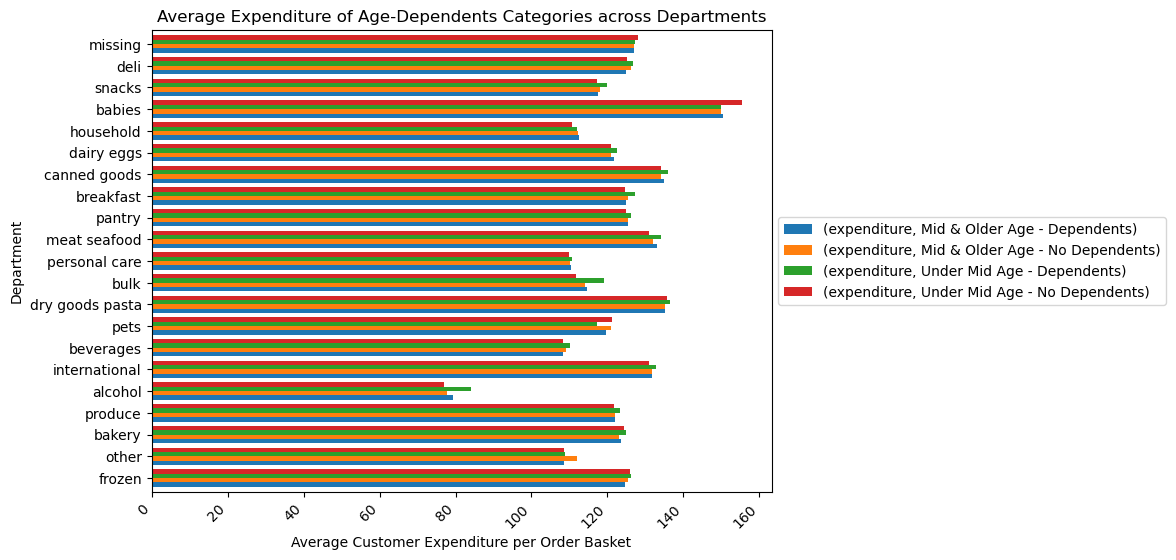

In [879]:
# Create a grouped bar chart from pivot_table_unstacked3

age_dept_exp_bar = pivot_table_unstacked3.plot(kind='barh', figsize=(8, 6), width=0.8)

plt.title('Average Expenditure of Age-Dependents Categories across Departments')
plt.xlabel('Average Customer Expenditure per Order Basket')
plt.ylabel('Department')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45, ha='right')
plt.show()

In [881]:
# Export grouped horizontal bar chart
age_dept_exp_bar.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'age_dept_exp_bar.png'), bbox_inches = 'tight')

# 09. Poking around

# Are there gender-based differences in ordering behavior?

In [899]:
# Compare gender ordering on the average expenditure per order basket metric
ords_prods_cust.groupby('gender')['expenditure'].mean()

gender
Female    122.411998
Male      122.051110
Name: expenditure, dtype: float64

In [983]:
# Check the periodicity of gender ordering
piv_table_gender = ords_prods_cust.pivot_table(values = 'days_since_prior_order', index = 'gender', aggfunc = 'mean').round(2)
piv_table_gender

,days_since_prior_order
gender,
Female,10.79
Male,10.83


__Females and males are largely similar on their average spend and frequency of orders, in the 2 tables above.__

In [907]:
# Alternate script to calculate the above table, for practice
ords_prods_cust.groupby('gender')['days_since_prior_order'].mean()

gender
Female    10.794260
Male      10.825867
Name: days_since_prior_order, dtype: float64

# What are the top-selling products over time?  Any surprises?

In [1004]:
# Find the 10 top-selling products by total spending over time

top_prods = ords_prods_cust.pivot_table(values='prices', index='product_name', aggfunc='sum').sort_values('prices', ascending = False).head(10)
top_prods

,prices
product_name,
Banana,5573917.2
Bag of Organic Bananas,3773950.9
Large Lemon,2035558.0
Limes,1980839.7
Organic Baby Spinach,1900530.4
Organic Strawberries,1868712.4
Organic Whole Milk,1708979.2
Cucumber Kirby,1222478.4
Apple Honeycrisp Organic,1161120.9


__No surprises.  The top 10 products are in the most-popular 'produce' (9) and 'dairy eggs' (1) departments.__

# 10. Export dataframe

In [1010]:
# Check the dimensions
ords_prods_cust.shape

(30959687, 35)

In [1014]:
# Check column names
ords_prods_cust.columns

Index(['order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_period_of_day', 'max_order', 'loyalty_flag',
       'mean_price_per_order', 'spending_flag',
       'median_days_since_prior_order', 'order_frequency_flag', 'first_name',
       'last_name', 'gender', 'state_name', 'age', 'date_joined',
       'number_dependents', 'family_status', 'income', 'region', 'cust_prof_1',
       'cust_prof_2', 'expenditure'],
      dtype='object')

In [1016]:
# Check the output
ords_prods_cust.head(2)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,state_name,age,date_joined,number_dependents,family_status,income,region,cust_prof_1,cust_prof_2,expenditure
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Alabama,31,2019-02-17,3,married,40423,South,LI-D,MU-D,31.6
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Alabama,31,2019-02-17,3,married,40423,South,LI-D,MU-D,31.6


In [1022]:
# Check the output middle columns not visible in the output above

ords_prods_cust.iloc[0:2, 10:25]

,aisle_id,department_id,prices,price_range_loc,busiest_day,busiest_period_of_day,max_order,loyalty_flag,mean_price_per_order,spending_flag,median_days_since_prior_order,order_frequency_flag,first_name,last_name,gender
0,77,7,9.0,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer,Linda,Nguyen,Female
1,91,16,12.5,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer,Linda,Nguyen,Female


In [1024]:
# Export the altered ords_prods_cust as the final dataframe
ords_prods_cust.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'orders_products_all.pkl'))